# Griffiths — Ten Problems on the Electric Potential

A self-contained run through the *potential* arc of Griffiths (Ch. 2.3 → 3.4): compute $V$ directly,
get the energy, expand far fields in multipoles, and solve Laplace's equation by separation of
variables. Companion to the two Regan sets (`regan_ps1_relativity.ipynb`, `regan_ps2_electrostatics.ipynb`).

**The ten I picked** (a coherent path, easy → boundary-value):

| # | problem | topic |
|---|---------|-------|
| 1 | G2.21 | $V$ of a uniform solid sphere (in/out) + field check |
| 2 | G2.27 | $V$ on the axis of a charged disk |
| 3 | G2.33 | energy of the sphere, $W=\tfrac35 k_e Q^2/R$ |
| 4 | G2.34 | the same energy the *other* way, $W=\tfrac12\!\int\!\rho V$ |
| 5 | G3.33 | the pure dipole: $V$ and $\mathbf E=-\nabla V$ |
| 6 | G3.28 | multipole moments (monopole / dipole / quadrupole) |
| 7 | G3.3 | Laplace mean-value property (⇒ Earnshaw) |
| 8 | G3.13 | Cartesian separation of variables (Fourier slot) |
| 9 | G3.18 | spherical separation of variables (Legendre) |
| 10 | G3.36 | dipole field pattern + the multipole hierarchy |

Engine: `griffiths.potential_theory` (added for this set).

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from sympy import oo, pi
from IPython.display import display, Math

import griffiths as gr
from griffiths import potential_theory as pt
from griffiths import electrostatics as es
from griffiths import x, y, z

sp.init_printing(use_latex="mathjax")
Q, R, r, sigma, p, V0, a = sp.symbols("Q R r sigma p V_0 a", positive=True)
theta, q, d = sp.symbols("theta q d", positive=True)
print("griffiths.potential_theory loaded; k_e =", sp.latex(es.KE))

griffiths.potential_theory loaded; k_e = \frac{1}{4 \pi \epsilon_{0}}


## §1 — G2.21: potential of a uniform solid sphere

Integrate the field ($V=-\int_\infty^r \mathbf E\cdot d\mathbf l$). Outside it is the point-charge
$k_eQ/r$; inside, $V$ keeps rising to a finite plateau. The field is recovered as $-\nabla V$.

In [2]:
V = pt.sphere_potential(Q, r, R)
display(Math(r"V(r) = " + sp.latex(V)))
# field check: -dV/dr inside reproduces Gauss's kQr/R^3
Vin = es.KE * Q / (2 * R) * (3 - r**2 / R**2)
display(Math(r"r<R:\ -\frac{dV}{dr} = " + sp.latex(sp.simplify(-sp.diff(Vin, r)))
             + r" = \frac{1}{4\pi\epsilon_0}\frac{Qr}{R^3}\ \checkmark"))
print("continuous at r=R:", sp.simplify(Vin.subs(r, R) - es.KE * Q / R) == 0,
      "| center value V(0) = 3kQ/2R")

<IPython.core.display.Math object>

<IPython.core.display.Math object>

continuous at r=R: True | center value V(0) = 3kQ/2R


## §2 — G2.27: potential on the axis of a charged disk

Stack rings $dq=\sigma\,2\pi s\,ds$ at distance $\sqrt{s^2+Z^2}$:
$V=\frac{\sigma}{2\epsilon_0}\bigl(\sqrt{R^2+Z^2}-Z\bigr)$. Far away it becomes a point charge;
the field $-dV/dZ$ matches the disk field from Ch. 2.

In [3]:
Z = sp.Symbol("Z", positive=True)
Vd = pt.disk_potential(sigma, R, Z)
display(Math(r"V(Z) = " + sp.latex(Vd)))
display(Math(r"Z\gg R:\ V \to " + sp.latex(sp.simplify(sp.series(Vd, Z, oo, 2).removeO()))
             + r" = \frac{1}{4\pi\epsilon_0}\frac{q}{Z},\quad q=\sigma\pi R^2"))
display(Math(r"-\frac{dV}{dZ} = " + sp.latex(sp.simplify(-sp.diff(Vd, Z)))
             + r"\quad(\text{the on-axis disk field})"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## §3 — G2.33: energy of the uniform sphere from the field

$W=\frac{\epsilon_0}{2}\int E^2\,d\tau$ over *all* space (inside $E\propto r$, outside $E\propto1/r^2$):

$$W=\frac{3}{5}\,\frac{1}{4\pi\epsilon_0}\frac{Q^2}{R}=\frac{3Q^2}{20\pi\epsilon_0 R}.$$

In [4]:
W_field = pt.energy_uniform_sphere(Q, R)
display(Math(r"W = \frac{\epsilon_0}{2}\int E^2\,d\tau = " + sp.latex(W_field)
             + r" = \frac{3}{5}\frac{1}{4\pi\epsilon_0}\frac{Q^2}{R}"))
assert sp.simplify(W_field - sp.Rational(3, 5) * es.KE * Q**2 / R) == 0

<IPython.core.display.Math object>

## §4 — G2.34: the same energy the *other* way

$W=\frac12\int\rho V\,d\tau$ over the charge only (inside the sphere), with $\rho=Q/\tfrac43\pi R^3$
and $V$ from §1. It must give the identical $\tfrac35 k_eQ^2/R$ — a satisfying cross-check that the
energy lives "in the field" and "in the assembly" equally.

In [5]:
rho = Q / (sp.Rational(4, 3) * pi * R**3)
Vin = es.KE * Q / (2 * R) * (3 - r**2 / R**2)
W_charge = sp.simplify(sp.Rational(1, 2) * sp.integrate(rho * Vin * 4 * pi * r**2, (r, 0, R)))
display(Math(r"W = \tfrac12\int\rho V\,d\tau = " + sp.latex(W_charge)))
print("matches the field-energy result?",
      sp.simplify(W_charge - W_field) == 0)

<IPython.core.display.Math object>

matches the field-energy result? True


## §5 — G3.33: the pure dipole

$V=\dfrac{1}{4\pi\epsilon_0}\dfrac{p\cos\theta}{r^2}$, and the field is $\mathbf E=-\nabla V$ in
spherical coordinates: $E_r=\dfrac{2k_ep\cos\theta}{r^3}$, $E_\theta=\dfrac{k_ep\sin\theta}{r^3}$.

In [6]:
Vdip = pt.dipole_potential(p, r, theta)
Er, Eth = pt.dipole_field(p, r, theta)
display(Math(r"V = " + sp.latex(Vdip)))
display(Math(r"E_r = " + sp.latex(Er) + r",\qquad E_\theta = " + sp.latex(Eth)))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## §6 — G3.28: multipole moments

Any localized charge cloud looks, from far away, like monopole + dipole + quadrupole + …
$\bigl(V=\tfrac{1}{4\pi\epsilon_0}\sum_n \tfrac{1}{r^{n+1}}\!\int(r')^nP_n\,\rho\,d\tau'\bigr)$.
Two textbook configurations: a physical dipole ($+q,-q$) and a linear quadrupole ($+q,-2q,+q$).

In [7]:
mono, dip, quad = pt.multipole_moments([q, -q], [[0, 0, d/2], [0, 0, -d/2]])
display(Math(r"\text{dipole config: } Q=" + sp.latex(mono)
             + r",\ \mathbf p = " + sp.latex(dip.T) + r" = q\,d\,\hat z"))

mono2, dip2, quad2 = pt.multipole_moments([q, -2*q, q], [[0, 0, d], [0, 0, 0], [0, 0, -d]])
display(Math(r"\text{linear quadrupole: } Q=" + sp.latex(mono2)
             + r",\ \mathbf p=" + sp.latex(dip2.T)
             + r",\ Q_{zz}=" + sp.latex(quad2[2, 2]) + r"=4qd^2"))
print("the leading non-zero moment sets the far-field falloff: monopole ~1/r, dipole ~1/r^2, "
      "quadrupole ~1/r^3.")

<IPython.core.display.Math object>

<IPython.core.display.Math object>

the leading non-zero moment sets the far-field falloff: monopole ~1/r, dipole ~1/r^2, quadrupole ~1/r^3.


## §7 — G3.3: Laplace's mean-value property (and Earnshaw)

In charge-free space $\nabla^2V=0$, and a harmonic function equals its own average over any sphere
about a point. Consequence: $V$ has **no local maxima or minima** in free space — so no arrangement
of fixed charges can trap a test charge in stable equilibrium (**Earnshaw's theorem**).

In [8]:
# demonstrate on the harmonic V = x^2 - y^2: center value == circle average
Vh = x**2 - y**2
x0, y0 = sp.symbols("x_0 y_0", real=True)
Vc, avg = pt.mean_value_check(Vh, (x0, y0), sp.Symbol("a", positive=True))
display(Math(r"V=x^2-y^2:\quad V(\text{center}) = " + sp.latex(Vc)
             + r",\quad \langle V\rangle_{\text{circle}} = " + sp.latex(avg)
             + (r"\quad\checkmark" if sp.simplify(Vc - avg) == 0 else r"\quad\ne")))
print("x^2 - y^2 harmonic?", pt.is_harmonic(Vh),
      " | x^2 + y^2 harmonic?", pt.is_harmonic(x**2 + y**2),
      "-> the latter has curvature, can't be a vacuum potential")

<IPython.core.display.Math object>

x^2 - y^2 harmonic? True  | x^2 + y^2 harmonic? False -> the latter has curvature, can't be a vacuum potential


## §8 — G3.13: Cartesian separation of variables (the slot)

Two grounded plates at $y=0,a$; the end at $x=0$ held at $V_0$; $V\to0$ as $x\to\infty$. Separation
$V=X(x)Y(y)$ forces $Y=\sin(n\pi y/a)$, $X=e^{-n\pi x/a}$, and matching $V_0$ at $x=0$ gives the
Fourier series

$$V(x,y)=\frac{4V_0}{\pi}\sum_{n\,\text{odd}}\frac1n\,e^{-n\pi x/a}\sin\!\frac{n\pi y}{a}.$$

<IPython.core.display.Math object>

each term harmonic, BCs V(x,0)=V(x,a)=0: True True True


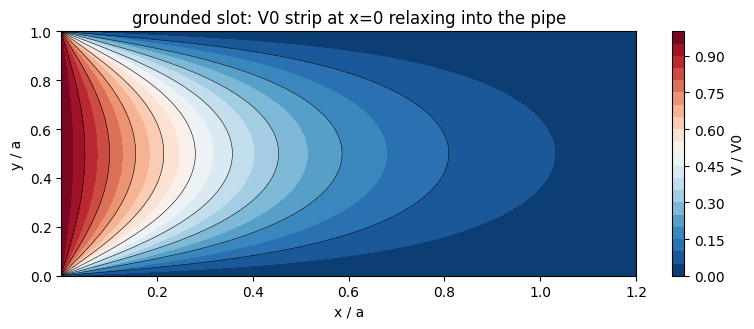

In [9]:
Vslot = pt.cartesian_slot(V0, a, 6, x, y)
display(Math(r"V \approx " + sp.latex(Vslot)))
print("each term harmonic, BCs V(x,0)=V(x,a)=0:", pt.is_harmonic(Vslot, (x, y, z)),
      sp.simplify(Vslot.subs(y, 0)) == 0, sp.simplify(Vslot.subs(y, a)) == 0)

# plot the equipotentials
f = sp.lambdify((x, y), pt.cartesian_slot(1.0, 1.0, 80, x, y), "numpy")
xg = np.linspace(0.001, 1.2, 200); yg = np.linspace(0, 1, 200)
XX, YY = np.meshgrid(xg, yg)
VV = np.clip(f(XX, YY), 0, 1)
plt.figure(figsize=(8, 3.4))
cs = plt.contourf(XX, YY, VV, levels=20, cmap="RdBu_r")
plt.colorbar(cs, label="V / V0")
plt.contour(XX, YY, VV, levels=10, colors="k", linewidths=0.4)
plt.xlabel("x / a"); plt.ylabel("y / a")
plt.title("grounded slot: V0 strip at x=0 relaxing into the pipe")
plt.tight_layout(); plt.show()

## §9 — G3.18: spherical separation of variables (Legendre)

A sphere whose surface is held at $V(R,\theta)$. Inside, $V=\sum_l A_l r^lP_l(\cos\theta)$; outside,
$V=\sum_l B_l r^{-(l+1)}P_l$. Projecting the surface potential onto Legendre polynomials fixes the
coefficients. For $V(R,\theta)=V_0\cos\theta=V_0P_1$, only $l=1$ survives.

<IPython.core.display.Math object>

<IPython.core.display.Math object>

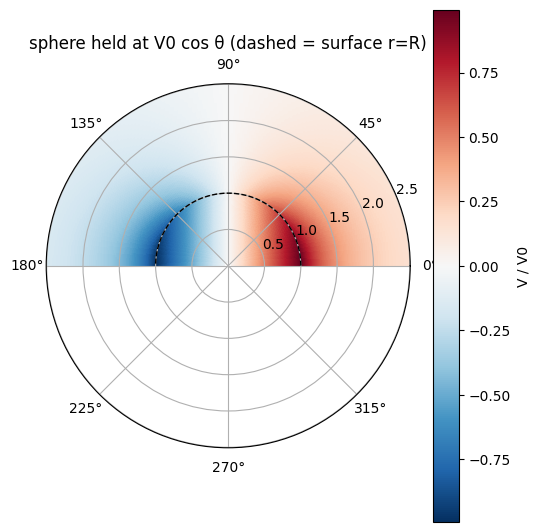

: 

In [ ]:
Vin_s = pt.legendre_sphere(V0 * sp.cos(theta), R, r, theta, n_max=4, inside=True)
Vout_s = pt.legendre_sphere(V0 * sp.cos(theta), R, r, theta, n_max=4, inside=False)
display(Math(r"r<R:\ V = " + sp.latex(Vin_s) + r" = V_0\frac{r}{R}\cos\theta"))
display(Math(r"r>R:\ V = " + sp.latex(Vout_s) + r" = V_0\frac{R^2}{r^2}\cos\theta"))

# polar plot of the full (inside+outside) potential for surface V0 cos(theta)
th = np.linspace(0, np.pi, 180); rr = np.linspace(0.05, 2.5, 180)
TH, RR = np.meshgrid(th, rr)
Vfield = np.where(RR < 1, RR * np.cos(TH), np.cos(TH) / RR**2)   # R=V0=1
fig, ax = plt.subplots(subplot_kw={"projection": "polar"}, figsize=(5.5, 5.5))
c = ax.pcolormesh(TH, RR, Vfield, cmap="RdBu_r", shading="auto")
ax.plot(th, np.ones_like(th), "k--", lw=1)
fig.colorbar(c, label="V / V0"); ax.set_title("sphere held at V0 cos θ (dashed = surface r=R)")
plt.tight_layout(); plt.show()

## §10 — G3.36 & the throughline

The dipole of §5 is the $n{=}1$ term of §6's multipole tower, and §6's "leading non-zero moment
wins at large $r$" is why a neutral molecule still has a field ($\sim1/r^3$). The bigger arc:

- **Direct $V$ then $\mathbf E=-\nabla V$** (§1–§5): potential is the scalar shortcut — one integral
  instead of three vector components, the reason it is the workhorse.
- **Laplace + separation of variables** (§8–§9): the *same* eigenfunction machinery as quantum wells
  (`applied_qm_engineering.ipynb`) and the spectral layers of the FNO — $\sin(n\pi y/a)$ and
  $P_l(\cos\theta)$ are the Fourier/Legendre bases the whole repo runs on.
- **Mean-value ⇒ Earnshaw** (§7): "nature won't hold a charge still with static fields" — the same
  no-free-lunch flavor as the rogue-wave statistics; you need *dynamics* (or feedback, or a trap
  that moves) to confine, which is exactly why the optical work leans on time-domain control.

Engine added this session: `griffiths/potential_theory.py` (sphere/disk potentials, energy, dipole,
multipole moments, Laplace mean-value, Cartesian + spherical separation of variables), benchmarked in
`scripts/smoke_potential_theory.py`. The `griffiths` package now spans Ch. 1–3 plus relativity and QM.